In [1]:
import os
import pickle
import matplotlib.pyplot as plt
from lib.algorithms import PathFormulation, Objective, PathFormulationCVXPY, PathFormulationALCD
from lib.traffic_matrix import *
from lib.problem import Problem
from lib.graph_utils import check_feasibility
import copy
import pickle
import _pickle as cpickle
num_paths, edge_disjoint, dist_metric = (4, True, "min-hop")

### Compute difference between a candidate flow allocations (sol_dicts) and optimal flow allocation for a given problem

In [2]:
## Problem setup
# topo_fname = "../topologies/UsCarrier.json"
# tm_fname = "../traffic-matrices/poisson/UsCarrier_0.25_3500000.0_3e-05_16.pkl"
topo_fname = "../topologies/Kdl.json"
tm_fname = "/mnt/teal/traffic-matrices/bimodal/Kdl_0.2_(0.02:0.04)_(0.08:0.16)_16.pkl"
sol_dumps = "/mnt/solvers/traffic_engineering/outputs/ALCD-Kdl-20x0.1_bimodal_hard.pkl"
cand_dumps = "/mnt/solvers/traffic_engineering/outputs/LPALL-Kdl-20x0.1_bimodal_hard.pkl"
tm_dumps = "/mnt/solvers/traffic_engineering/dumps/Kdl.20x0.1.uniform_updates_bimodal_hard.pkl"
sol_dump = pickle.load(open(sol_dumps, "rb"))
cand_dump = pickle.load(open(cand_dumps, "rb"))
problem = Problem.from_file(topo_fname, tm_fname)
tm = problem._traffic_matrix
mod_tms = pickle.load(open(tm_dumps, "rb"))
num_rounds = len(mod_tms)

Invalidating commodity lists..


In [3]:
mod_tms[0][0, 1]

0.4223442213914786

In [3]:
# Create path formulation
log = open("/tmp/path_formulation.txt", "w")
pf = PathFormulationALCD(objective=Objective.get_obj_from_str("total_flow"), 
                         num_paths=num_paths, edge_disjoint=edge_disjoint, 
                         dist_metric=dist_metric,out=log, VERBOSE=True)
pf.state = {}
allocs_list = []
demands_list = []
lp_runtimes = []
state = {}

In [7]:
def soldict_to_flowvals(sol_dict):
  flow_vals = {}
  for k, v in sol_dict.items():
    i, (src, dest, demand) = k
    cflow = 0
    if len(v) > 0:
      for (s, d), eflow in v:
        if s == src:
          cflow += eflow
    flow_vals[(src, dest)] = cflow
  return flow_vals

def commodlist_to_demands(commod_list):
  demands = {}
  for i, (src, dest, demand) in commod_list:
    demands[(src, dest)] = demand
  return demands

def get_total_flow(flow_vals, demands):
  total_flow = 0
  total_demand = 0
  for k in demands.keys():
    real_flow = min(flow_vals[k], demands[k])
    total_flow += real_flow
    total_demand += demands[k]
  return total_flow, total_demand

In [6]:
# Extract demands, solution and runtime for each round
for i in range(num_rounds):
  print(f"Round {i}")
  pf._problem = problem
  print(f"Updating traffic matrix...")
  problem._traffic_matrix.tm = mod_tms[i]
  print(f"Constructing LP...")
  if hasattr(pf, "_sol_dict"):
    del pf._sol_dict
  pf._construct_lp()
  pf._path_vars = sol_dump["x_opt"][i]
  print(f"Extracting solution...")
  allocs = soldict_to_flowvals(pf.sol_dict)
  allocs_list.append(allocs)
  print(f"Converting commodity list to demands...")
  demands = commodlist_to_demands(pf.commodity_list)
  demands_list.append(demands)
  lp_runtimes.append(cand_dump["solver_stats"][i]["solve_time"])

pickle.dump((allocs_list, demands_list, lp_runtimes), open("/mnt/solvers/traffic_engineering/opt_gap_analysis_Kdl.pkl", "wb"))

Round 0
Updating traffic matrix...
Invalidating commodity lists..
Constructing LP...
Generating commodity list ...
t=0.54s: commodity_list extracted, size=567762
Loading paths from pickle file /workspace/teal/pop-ncflow-lptop/../topologies/paths/path-form/Kdl.json-4-paths_edge-disjoint-True_dist-metric-min-hop-dict.pkl
paths_dict size: 567762
t=8.39s: paths_dict extracted, size=567762
t=18.20s: commodities processed
Pre Solve time: 18.20s
Constructing Path LP for ALCD solver
# Paths: 1064266
# Edges: 1790
t=0.14s: Processed edge capacity constraints..
# Commodities: 567762
t=0.71s: Processed demand constraints..
ALCD Constraint matrix: 569552 inequalities, 0 equalities, 30711354 non-zero entries
ALCD Variables: 1064266 non-basic, 0 free
t=12.09s: Finished all constraints..
Construct time: 12.22s
Extracting solution...
Converting commodity list to demands...
Round 1
Updating traffic matrix...
Invalidating commodity lists..
Constructing LP...
Generating commodity list ...
t=0.41s: commod

In [33]:
allocs_list, demands_list, lp_runtimes = pickle.load(open("/mnt/solvers/traffic_engineering/opt_gap_analysis_Kdl.pkl", "rb"))

In [34]:
round_duration = 300
pending_solve_time = 0
realized_total_flows = []
opt_total_flows = []
requested_demand = []
using_optimal_allocs = []
cur_allocs = None
for i in range(num_rounds):
  print(f"Processing round {i}")
  cur_demands = demands_list[i]
  # do we use optimal allocs this round?
  if pending_solve_time == 0:
    cur_allocs = allocs_list[i]
    pending_solve_time = max(lp_runtimes[i] - round_duration, 0)
    optimal_alloc = True
    print(f"Using optimal allocations for round {i}")
  else:
    pending_solve_time -= round_duration
    optimal_alloc = False
    pending_solve_time = max(pending_solve_time, 0)
    print(f"Re-using previous allocations for round {i}")
  # compute realized flow values and requested demand
  opt_allocs = allocs_list[i]
  opt_total_flow, total_demand = get_total_flow(opt_allocs, cur_demands)
  cur_total_flow, total_demand = get_total_flow(cur_allocs, cur_demands)
  print(f"Optimal: {opt_total_flow}, Realized: {cur_total_flow}, Requested: {total_demand}")
  # store values
  realized_total_flows.append(cur_total_flow)
  opt_total_flows.append(opt_total_flow)
  requested_demand.append(total_demand)
  using_optimal_allocs.append(optimal_alloc)
realized_total_flows = np.array(realized_total_flows)
opt_total_flows = np.array(opt_total_flows)
requested_demand = np.array(requested_demand)

Processing round 0
Using optimal allocations for round 0
Optimal: 425890.5785639798, Realized: 425890.5785639798, Requested: 436631.2406461666
Processing round 1
Re-using previous allocations for round 1
Optimal: 430215.936942125, Realized: 415937.36824362073, Requested: 436645.89701104234
Processing round 2
Re-using previous allocations for round 2
Optimal: 430086.64692448627, Realized: 412517.4439596941, Requested: 436615.99662853405
Processing round 3
Using optimal allocations for round 3
Optimal: 430352.6635357273, Realized: 430352.6635357273, Requested: 436594.978397452
Processing round 4
Re-using previous allocations for round 4
Optimal: 430332.6015047235, Realized: 420062.55456289335, Requested: 436591.27394544776
Processing round 5
Re-using previous allocations for round 5
Optimal: 430360.31448922347, Realized: 416536.32480411127, Requested: 436615.9079076636
Processing round 6
Re-using previous allocations for round 6
Optimal: 430392.5721459104, Realized: 413498.10731376405, R

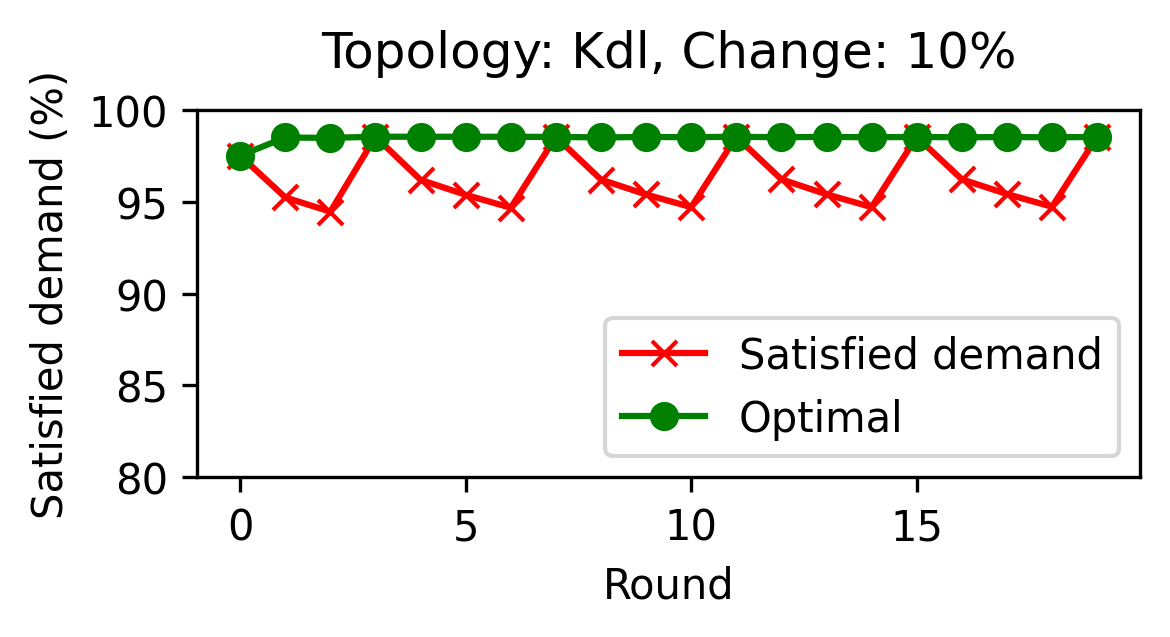

In [35]:
satisfied_demand = realized_total_flows / requested_demand
optimal_satisfied_demand = opt_total_flows / requested_demand
fig = plt.figure(figsize=(4, 2.25), dpi=300)
plt.plot(satisfied_demand * 100, label="Satisfied demand", marker='x', color='red')
plt.plot(optimal_satisfied_demand * 100, label="Optimal", marker='o', color='green')
plt.xlabel("Round")
plt.ylabel("Satisfied demand (%)")
plt.ylim(80, 100)
plt.title("Topology: Kdl, Change: 10%", y=1.05)
plt.tight_layout()
plt.legend(loc="lower right")
plt.savefig("/mnt/solvers/plots/te/opt_gap_Kdl_bimodal.pdf", bbox_inches='tight')

## Do the same for ASN

In [23]:
## Problem setup
topo_fname = "../topologies/ASN2k.json"
tm_fname = "/mnt/teal/traffic-matrices/bimodal/ASN_0.2_(0.02:0.04)_(0.08:0.16)_24.pkl"
sol_dumps = "/mnt/solvers/traffic_engineering/outputs/ALCD-ASN-20x0.1_bimodal_hard.pkl"
tm_dumps = "/mnt/solvers/traffic_engineering/dumps/ASN.20x0.1.uniform_updates_bimodal_hard.pkl"
sol_dump = pickle.load(open(sol_dumps, "rb"))
problem = Problem.from_file(topo_fname, tm_fname)
tm = problem._traffic_matrix
mod_tms = pickle.load(open(tm_dumps, "rb"))
num_rounds = len(mod_tms)

Invalidating commodity lists..


In [24]:
# Create path formulation
log = open("/tmp/path_formulation.txt", "w")
pf = PathFormulationALCD(objective=Objective.get_obj_from_str("total_flow"), 
                         num_paths=num_paths, edge_disjoint=edge_disjoint, 
                         dist_metric=dist_metric,out=log, VERBOSE=True)
pf.state = {}
allocs_list = []
demands_list = []
lp_runtimes = []
state = {}

In [25]:
pop_runtime = 1200
# Extract demands, solution and runtime for each round
for i in range(num_rounds):
  print(f"Round {i}")
  pf._problem = problem
  print(f"Updating traffic matrix...")
  problem._traffic_matrix.tm = mod_tms[i]
  print(f"Constructing LP...")
  if hasattr(pf, "_sol_dict"):
    del pf._sol_dict
  pf._construct_lp()
  pf._path_vars = sol_dump["x_opt"][i]
  print(f"Extracting solution...")
  allocs = soldict_to_flowvals(pf.sol_dict)
  allocs_list.append(allocs)
  print(f"Converting commodity list to demands...")
  demands = commodlist_to_demands(pf.commodity_list)
  demands_list.append(demands)
  lp_runtimes.append(pop_runtime)

pickle.dump((allocs_list, demands_list, lp_runtimes), open("/mnt/solvers/traffic_engineering/opt_gap_analysis_ASN.pkl", "wb"))

Round 0
Updating traffic matrix...
Invalidating commodity lists..
Constructing LP...
Generating commodity list ...
t=2.80s: commodity_list extracted, size=3022382
Loading paths from pickle file /workspace/teal/pop-ncflow-lptop/../topologies/paths/path-form/ASN2k.json-4-paths_edge-disjoint-True_dist-metric-min-hop-dict.pkl
paths_dict size: 3022382
t=21.03s: paths_dict extracted, size=3022382
t=43.43s: commodities processed
Pre Solve time: 43.43s
Constructing Path LP for ALCD solver
# Paths: 6737170
# Edges: 8558
t=0.18s: Processed edge capacity constraints..
# Commodities: 3022382
t=2.85s: Processed demand constraints..
ALCD Constraint matrix: 3030940 inequalities, 0 equalities, 32685281 non-zero entries
ALCD Variables: 6737170 non-basic, 0 free
t=19.23s: Finished all constraints..
Construct time: 19.52s
Extracting solution...
Converting commodity list to demands...
Round 1
Updating traffic matrix...
Invalidating commodity lists..
Constructing LP...
Generating commodity list ...
t=2.19s

In [ ]:
allocs_list, demands_list, lp_runtimes = pickle.load(open("/mnt/solvers/traffic_engineering/opt_gap_analysis_ASN.pkl", "rb"))

In [26]:
round_duration = 300
pending_solve_time = 0
realized_total_flows = []
opt_total_flows = []
requested_demand = []
using_optimal_allocs = []
cur_allocs = None
for i in range(num_rounds):
  print(f"Processing round {i}")
  cur_demands = demands_list[i]
  # do we use optimal allocs this round?
  if pending_solve_time == 0:
    cur_allocs = allocs_list[i]
    pending_solve_time = max(lp_runtimes[i] - round_duration, 0)
    optimal_alloc = True
    print(f"Using optimal allocations for round {i}")
  else:
    pending_solve_time -= round_duration
    optimal_alloc = False
    pending_solve_time = max(pending_solve_time, 0)
    print(f"Re-using previous allocations for round {i}")
  # compute realized flow values and requested demand
  opt_allocs = allocs_list[i]
  opt_total_flow, total_demand = get_total_flow(opt_allocs, cur_demands)
  cur_total_flow, total_demand = get_total_flow(cur_allocs, cur_demands)
  print(f"Optimal: {opt_total_flow}, Realized: {cur_total_flow}, Requested: {total_demand}")
  # store values
  realized_total_flows.append(cur_total_flow)
  opt_total_flows.append(opt_total_flow)
  requested_demand.append(total_demand)
  using_optimal_allocs.append(optimal_alloc)
realized_total_flows = np.array(realized_total_flows)
opt_total_flows = np.array(opt_total_flows)
requested_demand = np.array(requested_demand)

Processing round 0
Using optimal allocations for round 0
Optimal: 2880868.879567353, Realized: 2880868.879567353, Requested: 3482209.980668617
Processing round 1
Re-using previous allocations for round 1
Optimal: 2882555.740520486, Realized: 2834822.3807527157, Requested: 3482299.639062044
Processing round 2
Re-using previous allocations for round 2
Optimal: 2883633.7216682383, Realized: 2816908.9582465747, Requested: 3481931.5085261483
Processing round 3
Re-using previous allocations for round 3
Optimal: 2884606.1199547416, Realized: 2801142.1863831454, Requested: 3481949.12857219
Processing round 4
Using optimal allocations for round 4
Optimal: 2885394.111428262, Realized: 2885394.111428262, Requested: 3481944.499553005
Processing round 5
Re-using previous allocations for round 5
Optimal: 2886067.933122478, Realized: 2841531.7502112826, Requested: 3482030.234294376
Processing round 6
Re-using previous allocations for round 6
Optimal: 2886673.7878858754, Realized: 2824317.237360776, R

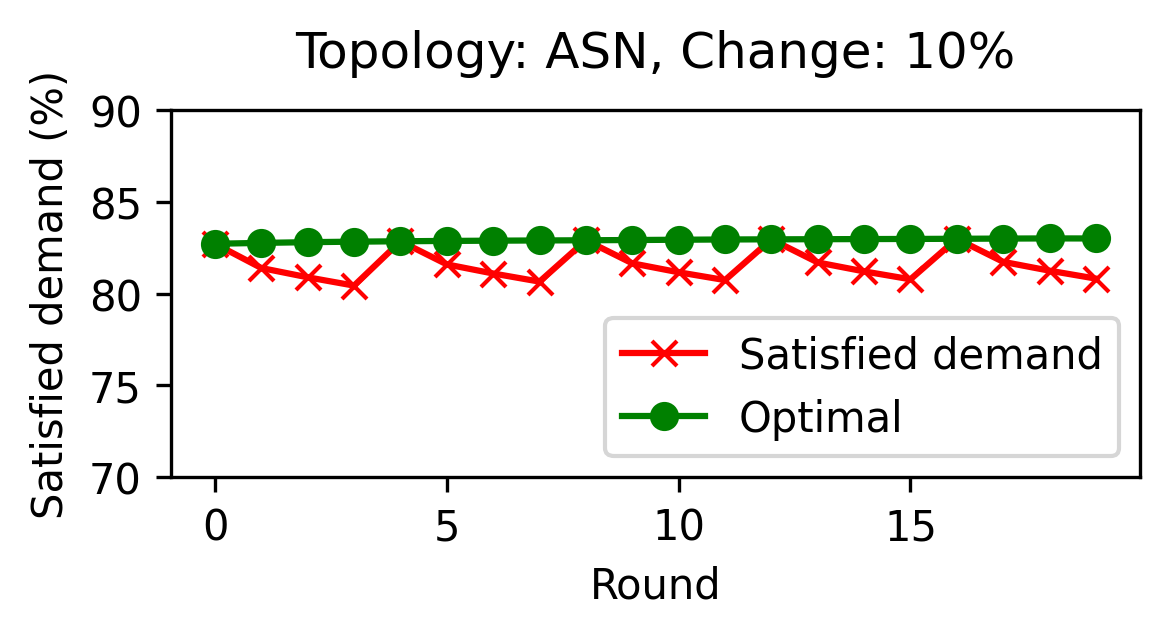

In [32]:
satisfied_demand = realized_total_flows / requested_demand
optimal_satisfied_demand = opt_total_flows / requested_demand
fig = plt.figure(figsize=(4, 2.25), dpi=300)
plt.plot(satisfied_demand * 100, label="Satisfied demand", marker='x', color='red')
plt.plot(optimal_satisfied_demand * 100, label="Optimal", marker='o', color='green')
plt.xlabel("Round")
plt.ylabel("Satisfied demand (%)")
plt.ylim(70, 90)
plt.title("Topology: ASN, Change: 10%", y=1.05)
plt.tight_layout()
plt.legend(loc="lower right")
plt.savefig("/mnt/solvers/plots/te/opt_gap_ASN_bimodal.pdf", bbox_inches='tight')